# RideMatch Colab Experiment Notebook

This notebook is the research surface for RideMatch. It generates synthetic fulfillment data, inspects the simulation, establishes the nearest-driver baseline, and provides a place to test improved ranking objectives.

The current `matched` label is generated by the nearest-driver policy. A model trained on it validates the pipeline but mostly learns to imitate that policy. Do not claim an ML improvement until policies are compared at the request level using wait, SLA, coverage, cancellation, and utilization metrics.

In [50]:
# Colab setup. Skip the clone cell when running locally from the repository.
# !git clone https://github.com/sohan2000/ride-match-ml.git
# %cd ride-match-ml
# !pip install -r requirements.txt matplotlib

from pathlib import Path
import os
import sys

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "src").exists():
    REPO_ROOT = REPO_ROOT.parent
os.chdir(REPO_ROOT)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

NUM_DRIVERS = 40
NUM_RIDERS = 600
SIMULATION_STEPS = 1_440
SEED = 42

print(f"Repository: {REPO_ROOT.resolve()}")
print(f"Experiment: {NUM_DRIVERS} drivers, {NUM_RIDERS} requests, {SIMULATION_STEPS} minutes, seed {SEED}")

Repository: /Users/sohan/Downloads/ride-match-ml
Experiment: 40 drivers, 600 requests, 1440 minutes, seed 42


In [51]:
import importlib
from pathlib import Path
import pandas as pd
import src.simulator.schema as schema
import src.simulator.generate_data as simulator_data

schema = importlib.reload(schema)
simulator_data = importlib.reload(simulator_data)

candidates = simulator_data.generate_dataset(
    num_drivers=NUM_DRIVERS,
    num_riders=NUM_RIDERS,
    steps=SIMULATION_STEPS,
    seed=SEED,
)
Path("data/processed").mkdir(parents=True, exist_ok=True)
candidates.to_csv("data/processed/colab_candidates.csv", index=False)
candidates.head()

,event_time,request_id,driver_id,distance_km,eta_minutes,driver_idle_minutes,available_drivers,open_requests,hour_of_day,matched,realized_wait_minutes,cancelled,candidate_utility,driver_acceptance_rate,same_pickup_zone,pickup_zone_supply,pickup_zone_demand_supply_ratio
0,2026-01-01T00:00:00+00:00,req-0000-00,d0,12.843,32.108,0.0,40,1,0,0,32.108,1,-106.973,0.0,0,0,1.0
1,2026-01-01T00:00:00+00:00,req-0000-00,d1,12.868,32.170,0.0,40,1,0,0,32.170,1,-107.207,0.0,0,0,1.0
2,2026-01-01T00:00:00+00:00,req-0000-00,d2,12.103,30.257,0.0,40,1,0,0,30.257,1,-99.999,0.0,0,0,1.0
3,2026-01-01T00:00:00+00:00,req-0000-00,d3,12.243,30.609,0.0,40,1,0,0,30.609,1,-101.324,0.0,0,0,1.0
4,2026-01-01T00:00:00+00:00,req-0000-00,d4,11.816,29.541,0.0,40,1,0,0,29.541,1,-97.301,0.0,0,0,1.0


In [52]:
print("Rows:", len(candidates))
print("Requests:", candidates["request_id"].nunique())
print("Candidate positive rate:", candidates["matched"].mean())
print("Candidates per request:")
print(candidates.groupby("request_id").size().describe())

display(candidates[[
    "distance_km",
    "eta_minutes",
    "driver_idle_minutes",
    "available_drivers",
    "open_requests",
    "hour_of_day",
]].describe())

Rows: 16029
Requests: 600
Candidate positive rate: 0.03743215422047539
Candidates per request:
count    600.000000
mean      26.715000
std        7.591211
min       10.000000
25%       19.000000
50%       28.000000
75%       33.000000
max       40.000000
dtype: float64


,distance_km,eta_minutes,driver_idle_minutes,available_drivers,open_requests,hour_of_day
count,16029.000000,16029.000000,16029.000000,16029.000000,16029.000000,16029.000000
mean,10.932562,27.331400,107.252854,28.868488,1.457047,11.638593
std,5.104254,12.760638,92.504886,7.005073,0.773665,6.648025
min,0.110000,0.275000,0.000000,10.000000,1.000000,0.000000
25%,7.005000,17.512000,45.000000,23.000000,1.000000,7.000000
50%,10.748000,26.871000,74.000000,32.000000,1.000000,11.000000
75%,14.736000,36.839000,143.000000,34.000000,2.000000,17.000000
max,26.501000,66.252000,614.000000,40.000000,5.000000,23.000000


In [53]:
from src.utils.metrics import marketplace_metrics
from src.simulator.generate_data import generate_outcomes

outcomes = generate_outcomes(
    num_drivers=NUM_DRIVERS,
    num_riders=NUM_RIDERS,
    steps=SIMULATION_STEPS,
    seed=SEED,
)

baseline_metrics = marketplace_metrics(outcomes.to_dict("records"), sla_minutes=5.0)
pd.Series(baseline_metrics, name="nearest_driver_baseline")

requests                600.000000
matched                 524.000000
match_coverage            0.873333
average_wait_minutes      6.218205
p90_wait_minutes         10.000000
sla_hit_rate              0.461667
cancellation_rate         0.126667
driver_utilization        0.000000
Name: nearest_driver_baseline, dtype: float64

In [54]:
from src.models.train_model import train_and_evaluate

# This mirrors the production trainer and saves a portable joblib artifact.
model_metrics = train_and_evaluate(
    "data/processed/colab_candidates.csv",
    "models/colab_gbdt.pkl",
)
pd.Series(model_metrics, name="gbdt_validation")

roc_auc          0.974673
precision        0.769231
recall           0.434783
positive_rate    0.037432
Name: gbdt_validation, dtype: float64

In [56]:
from src.models.evaluate import evaluate_ranking_policy

ranking_report = evaluate_ranking_policy(
    "models/colab_gbdt.pkl",
    "data/processed/colab_candidates.csv",
    sla_minutes=5.0,
)
pd.Series(ranking_report, name="request_level_policy_comparison")

requests_with_candidates        600.000000
model_ranking_accuracy            0.943333
model_average_eta_minutes         6.625205
baseline_average_eta_minutes      6.393100
eta_delta_minutes                 0.232105
model_sla_hit_rate                0.480000
baseline_sla_hit_rate             0.483333
model_cancellation_proxy          0.520000
baseline_cancellation_proxy       0.516667
model_utilization_proxy           0.168438
baseline_utilization_proxy        0.162537
Name: request_level_policy_comparison, dtype: float64

In [55]:
import importlib
import src.features.build_features as feature_building
import src.models.train_utility_model as utility_training

feature_building = importlib.reload(feature_building)
utility_training = importlib.reload(utility_training)
utility_metrics = utility_training.train_utility_model(
    "data/processed/colab_candidates.csv",
    "models/colab_utility_gbdt.pkl",
)
print("Utility validation:")
pd.Series(utility_metrics)

Utility validation:


validation_mae    0.461464
dtype: float64

In [57]:
import importlib
import src.models.tune_utility as tune_utility

tune_utility = importlib.reload(tune_utility)
sweep = tune_utility.tune_utility_weights()
summary = (
    sweep.groupby(["idle_weight", "cancellation_weight"])
    .agg(
        mean_eta_delta=("eta_delta_minutes", "mean"),
        std_eta_delta=("eta_delta_minutes", "std"),
        mean_coverage_delta=("coverage_delta", "mean"),
        mean_sla_delta=("sla_delta", "mean"),
        mean_utilization_delta=("utilization_delta", "mean"),
        mean_cancellation_delta=("cancellation_delta", "mean"),
        mean_policy_kpi_score=("policy_kpi_score", "mean"),
    )
    .reset_index()
    .sort_values("mean_policy_kpi_score", ascending=False)
)
summary.head(10)

,idle_weight,cancellation_weight,mean_eta_delta,std_eta_delta,mean_coverage_delta,mean_sla_delta,mean_utilization_delta,mean_cancellation_delta,mean_policy_kpi_score
0,0.00,4.0,-0.025267,1.513603,0.005000,-0.002500,-0.003771,-0.005000,0.058649
6,0.10,4.0,0.083854,1.222237,0.007083,-0.007500,-0.003079,-0.007083,-0.159038
4,0.05,8.0,0.185938,0.873973,-0.006250,-0.007083,-0.009597,0.006250,-0.399382
3,0.05,4.0,0.186746,1.424226,-0.006250,-0.016667,-0.001354,0.006250,-0.406460
5,0.05,12.0,0.233503,1.172059,-0.010000,-0.010417,-0.013570,0.010000,-0.509207
1,0.00,8.0,0.255159,1.376126,-0.004167,-0.016667,-0.003546,0.004167,-0.539175
2,0.00,12.0,0.283120,0.927676,0.000417,-0.013750,-0.005900,-0.000417,-0.581899
8,0.10,12.0,0.291255,1.238663,-0.002083,-0.010833,-0.008565,0.002083,-0.602835
7,0.10,8.0,0.501903,0.938421,-0.007917,-0.022500,-0.009037,0.007917,-1.050615


In [58]:
import importlib
import src.simulator.schema as schema
import src.simulator.generate_data as generate_data
import src.models.policy_eval as policy_eval

schema = importlib.reload(schema)
generate_data = importlib.reload(generate_data)
policy_eval = importlib.reload(policy_eval)

# Primary evaluation: replay both policies through the same driver state.
policy_results = policy_eval.compare_policies(
    "models/colab_utility_gbdt.pkl",
    num_drivers=NUM_DRIVERS,
    num_riders=NUM_RIDERS,
    steps=SIMULATION_STEPS,
    seed=SEED,
)
policy_results

,policy,requests,matched,coverage,average_wait_minutes,p90_wait_minutes,sla_hit_rate,driver_rejection_rate,rider_cancellation_rate,cancellation_rate,utilization,policy_kpi_score
0,nearest,600,524,0.873333,6.218205,10.0000,0.461667,0.09,0.036667,0.126667,0.204960,0.000000
1,model,600,499,0.831667,6.403335,10.3469,0.436667,0.12,0.048333,0.168333,0.197398,-0.503208


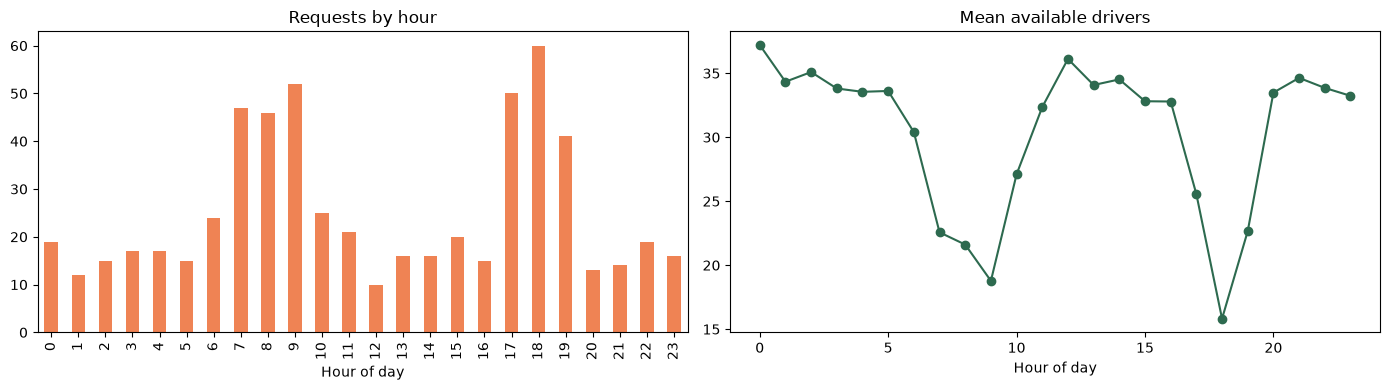

In [59]:
import matplotlib.pyplot as plt

# 1. Demand and supply over the simulated day.
demand_by_hour = candidates.groupby("hour_of_day")["request_id"].nunique()
supply_by_hour = candidates.groupby("hour_of_day")["available_drivers"].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
demand_by_hour.plot(kind="bar", ax=axes[0], color="#ef8354", title="Requests by hour")
supply_by_hour.plot(kind="line", marker="o", ax=axes[1], color="#2d6a4f", title="Mean available drivers")
axes[0].set_xlabel("Hour of day")
axes[1].set_xlabel("Hour of day")
plt.tight_layout()
plt.show()

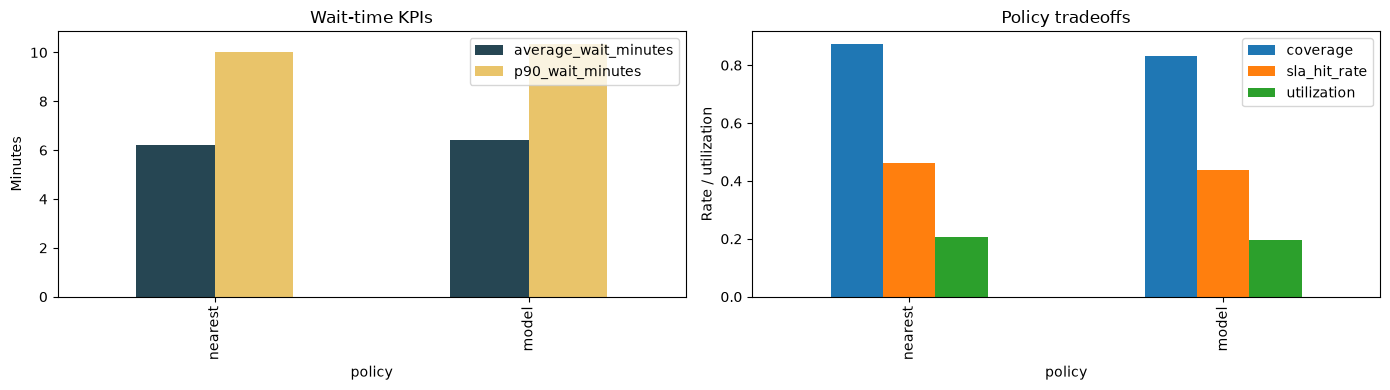

,policy,requests,matched,coverage,average_wait_minutes,p90_wait_minutes,sla_hit_rate,driver_rejection_rate,rider_cancellation_rate,cancellation_rate,utilization,policy_kpi_score
0,nearest,600,524,0.873333,6.218205,10.0000,0.461667,0.09,0.036667,0.126667,0.204960,0.000000
1,model,600,499,0.831667,6.403335,10.3469,0.436667,0.12,0.048333,0.168333,0.197398,-0.503208


In [60]:
# 2. Wait-time distribution for the baseline and learned policy.
from src.models.policy_eval import compare_policies

policy_results = compare_policies(
    "models/colab_utility_gbdt.pkl",
    num_drivers=NUM_DRIVERS,
    num_riders=NUM_RIDERS,
    steps=SIMULATION_STEPS,
    seed=SEED,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
policy_results.set_index("policy")[["average_wait_minutes", "p90_wait_minutes"]].plot(
    kind="bar", ax=axes[0], color=["#264653", "#e9c46a"], title="Wait-time KPIs"
)
policy_results.set_index("policy")[["coverage", "sla_hit_rate", "utilization"]].plot(
    kind="bar", ax=axes[1], title="Policy tradeoffs"
)
axes[0].set_ylabel("Minutes")
axes[1].set_ylabel("Rate / utilization")
plt.tight_layout()
plt.show()

policy_results

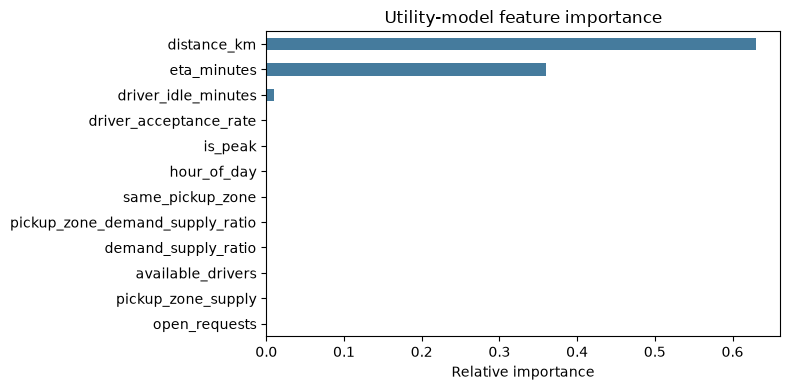

In [61]:
# 3. Inspect what the utility GBDT learned.
import joblib

utility_artifact = joblib.load("models/colab_utility_gbdt.pkl")
utility_model = utility_artifact["model"]
importance = pd.Series(
    utility_model.feature_importances_,
    index=utility_artifact["feature_columns"],
).sort_values()

importance.plot(kind="barh", figsize=(8, 4), color="#457b9d", title="Utility-model feature importance")
plt.xlabel("Relative importance")
plt.tight_layout()
plt.show()

In [62]:
# 4. Validate feature behavior on held-out time data.
from src.models.feature_importance import permutation_feature_importance

permutation_importance_report = permutation_feature_importance(
    "models/colab_utility_gbdt.pkl",
    "data/processed/colab_candidates.csv",
    repeats=10,
)
permutation_importance_report

,feature,importance_mean,importance_std
0,distance_km,27.634158,0.416408
1,eta_minutes,22.994664,0.279915
2,driver_idle_minutes,3.057936,0.025512
3,is_peak,0.428547,0.010176
4,same_pickup_zone,0.088556,0.003113
5,driver_acceptance_rate,0.072501,0.003066
6,pickup_zone_demand_supply_ratio,0.044578,0.001848
7,demand_supply_ratio,0.005980,0.000198
8,available_drivers,0.001452,0.000114
9,open_requests,0.000000,0.000000


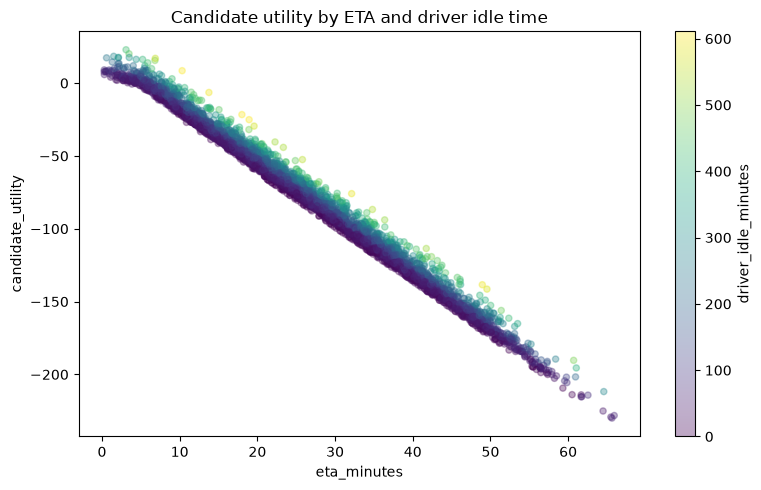

In [63]:
# 5. Visualize the synthetic utility landscape.
plot_data = candidates.sample(min(5_000, len(candidates)), random_state=42)
plot_data.plot.scatter(
    x="eta_minutes",
    y="candidate_utility",
    c="driver_idle_minutes",
    colormap="viridis",
    alpha=0.35,
    figsize=(8, 5),
    title="Candidate utility by ETA and driver idle time",
)
plt.tight_layout()
plt.show()

## Outcome-aware policy comparison

The baseline label is policy-generated. The outcome-aware replay below is the primary result: it measures driver rejection, rider cancellation, coverage, wait, SLA, and utilization after each policy changes future driver state. The current utility model is a baseline experiment and must beat nearest-driver across multiple seeds before being presented as an improvement.